In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pyarrow import dataset as ds

plt.style.use("custom_rose_dark")
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]


datapath = Path("dataset")

In [2]:
ymeta = pd.read_feather(
    datapath / "yt_metadata_helper.feather",
    columns=["categories", "upload_date", "view_count"],
)
cats = ymeta["categories"].unique()
cats.sort()
cats = cats[(cats != "Movies") & (cats != "Shows")]

res = (
    ymeta.groupby(["categories", "upload_date"])
    .agg({"view_count": "sum"})
    .reset_index(level=-1)
)

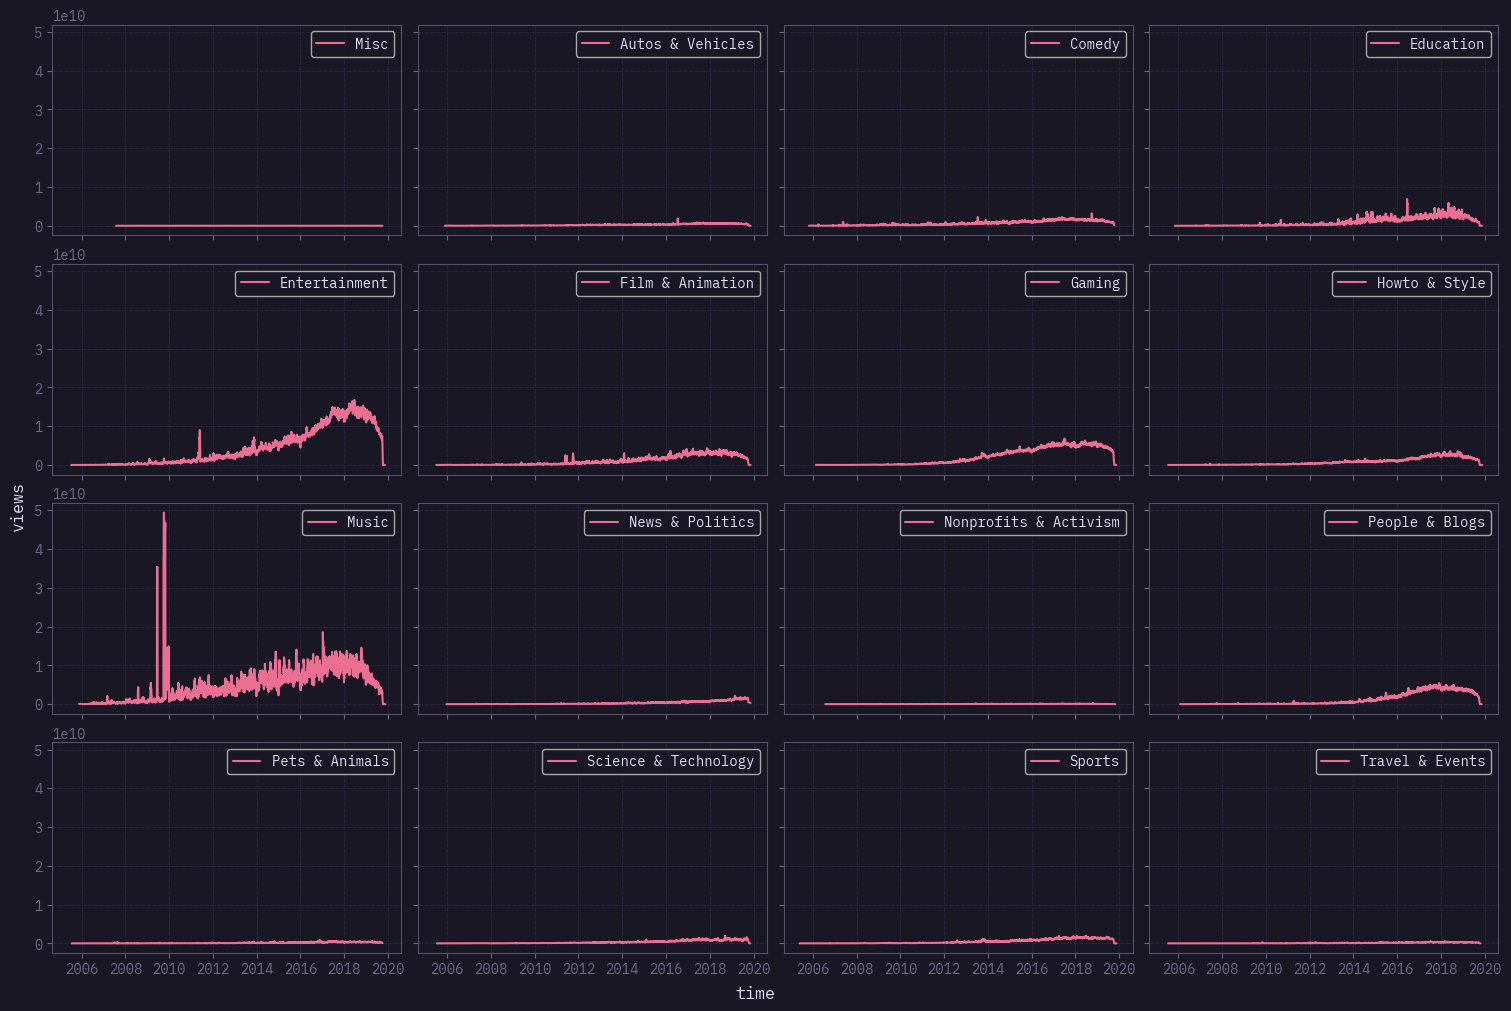

In [3]:
fig, axs = plt.subplots(
    4, 4, sharex=True, sharey=True, figsize=(15, 10), layout="constrained"
)
for cat, ax in zip(cats, axs.flatten()):
    ax.plot(
        res.loc[cat]["upload_date"],
        np.convolve(
            res.loc[cat]["view_count"].to_numpy(), np.ones(10), mode="same"
        ),
        label="Misc" if cat == "" else cat,
    )
    ax.legend()

fig.supxlabel("time")
fig.supylabel("views")
plt.show()

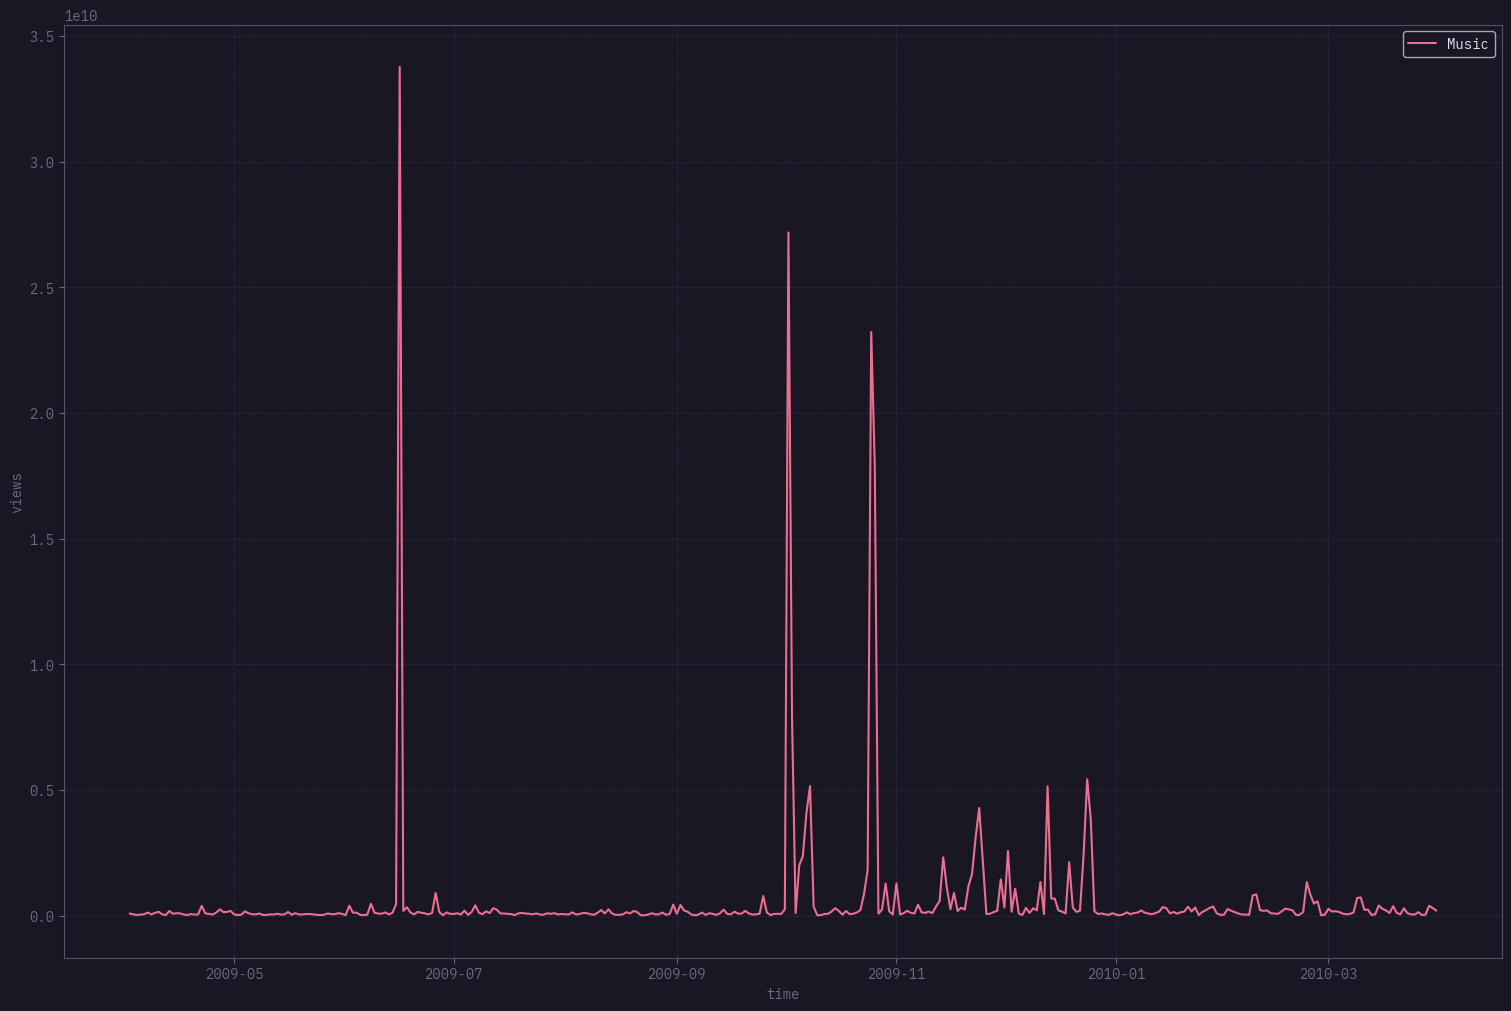

In [4]:
fig = plt.figure(figsize=(15, 10), layout="constrained")
music = res.loc["Music"]
interesting = (music["upload_date"] > datetime(2009, 4, 1)) & (
    music["upload_date"] < datetime(2010, 4, 1)
)
plt.plot(
    music[interesting]["upload_date"],
    music[interesting]["view_count"].to_numpy(),
    label="Music",
)
plt.legend()
plt.xlabel("time")
plt.ylabel("views")
plt.show()

In [5]:
full = ds.dataset(datapath / "yt_metadata_helper.feather", format="feather")
inter = full.to_table(
    filter=(ds.field("upload_date") > datetime(2009, 6, 1))
    & (ds.field("upload_date") < datetime(2009, 12, 1))
).to_pandas()
max_views = inter.sort_values("view_count", ascending=False)
max_views

,categories,channel_id,dislike_count,display_id,duration,like_count,upload_date,view_count
343398,Music,UC4XR0EZ0oHwSV2XhhShzX5A,1243468.0,k85mRPqvMbE,173,6820301.0,2009-06-16,1.852128e+09
369867,Music,UC07Kxew-cMIaykMOkzqHtBQ,387326.0,qrO4YZeyl0I,308,4126892.0,2009-11-24,1.132275e+09
303335,Music,UCANLZYMidaCbLQFWXBC95Jg,183838.0,VuNIsY6JdUw,229,4874674.0,2009-06-16,1.005140e+09
270677,Music,UCF9i903aeMcvcapmP1bS1oA,190369.0,6Ejga4kJUts,315,4549259.0,2009-06-16,9.683380e+08
304292,Music,UC9zX2xZIJ4cnwRsgBpHGvMg,148079.0,bnVUHWCynig,224,4106322.0,2009-10-03,9.540949e+08
...,...,...,...,...,...,...,...,...
216432,People & Blogs,UCNDgLGkieihqa2zDdSDxunQ,0.0,ayIjrxiepKk,10,0.0,2009-07-27,0.000000e+00
216457,People & Blogs,UCNDgLGkieihqa2zDdSDxunQ,0.0,UxNcWwLWnHc,10,0.0,2009-07-27,0.000000e+00
129738,News & Politics,UC_B1lpgj2DH_wO8T1jJnSYA,0.0,hi9u0G0z4Pc,65,0.0,2009-07-23,0.000000e+00
216446,People & Blogs,UCNDgLGkieihqa2zDdSDxunQ,0.0,GRtLRWGBX_I,8,0.0,2009-07-27,0.000000e+00


In [6]:
from IPython.display import YouTubeVideo

max_ids = max_views[:3]["display_id"].to_list()
print(max_ids)
# chunks = pd.read_json(
#     datapath / "yt_metadata_en.jsonl.gz", lines=True, chunksize=10000
# )
# for chunk in chunks:
#     max_vids = chunk[chunk["display_id"].isin(max_ids)]
#     if not max_vids.empty:
#         print(max_vids)

['k85mRPqvMbE', 'qrO4YZeyl0I', 'VuNIsY6JdUw']


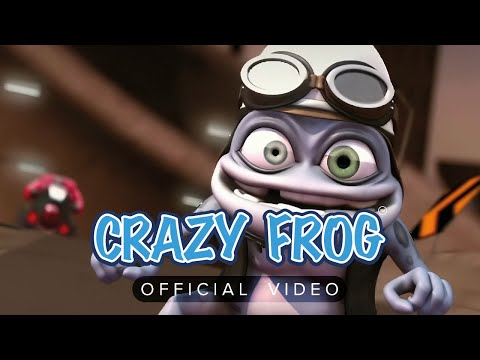

In [7]:
YouTubeVideo(max_ids[0])

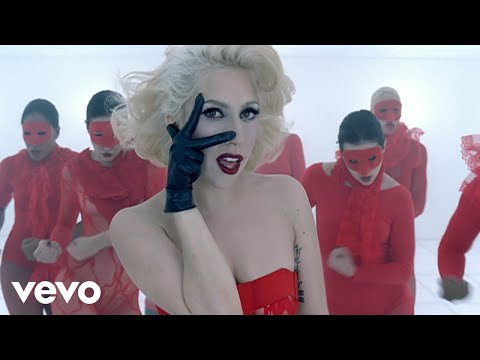

In [8]:
YouTubeVideo(max_ids[1])

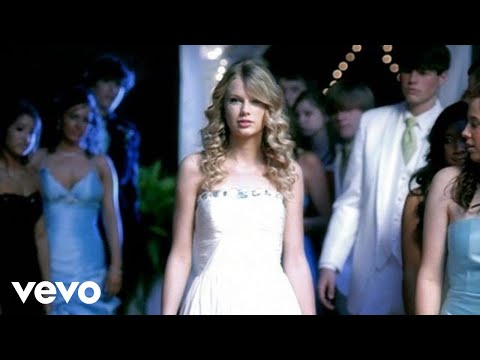

In [9]:
YouTubeVideo(max_ids[2])